<a href="https://colab.research.google.com/github/AP-Common-Projects/nanograd/blob/main/engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import math

In [2]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value({float(self.data)})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    return out

  def zero_grad(self):
    self.grad = 0.0

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for v in reversed(topo):
      v._backward()

In [3]:
a = Value(4)
b = Value(3)

c = a * b
print(c)
print(c._prev)

Value(12.0)
{Value(3.0), Value(4.0)}


## Graphviz visualization

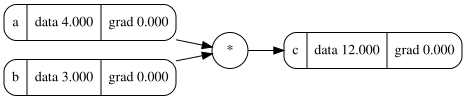

In [4]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    label = "{ %s | data %.3f | grad %.3f }" % (n.label, n.data, n.grad)
    if n._op:
        dot.node(name=uid, label=label, shape='Mrecord')
        dot.node(name=uid + n._op, label=n._op, shape='circle')
        dot.edge(uid + n._op, uid)
    else:
        dot.node(name=uid, label=label, shape='Mrecord')

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

# Re-create c with labels so they show up in the graph
a = Value(4, label='a')
b = Value(3, label='b')
c = a * b; c.label = 'c'

draw_dot(c)

In [5]:
a = Value(0.52, label = 'a')
b = Value(0.77, label = 'b')
h = Value(0.134, label = 'h')
i = Value(0.65, label = 'i')
j = Value(0.11, label = 'j')

c = a + b; c.label = 'c'
d = c * h; d.label = 'd'
e = d + c; e.label = 'e'
f = i + d; f.label = 'f'
g = f * j; g.label = 'g'
L = g.tanh(); L.label = 'L'

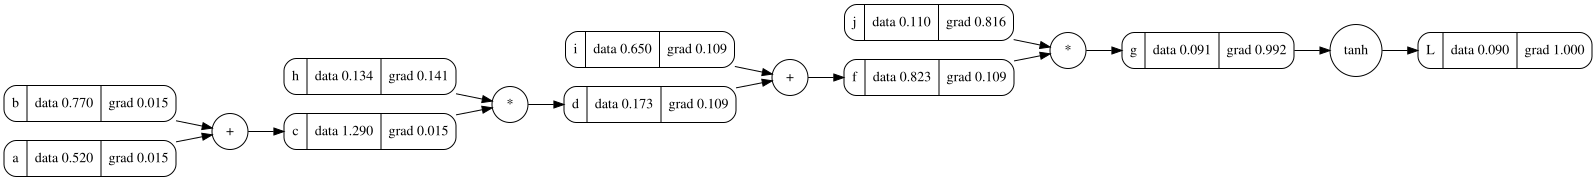

In [6]:
L.backward()
draw_dot(L)

In [7]:
a = np.zeros((3, 3))
w = np.random.rand(3, 3)
b = np.zeros((1, 3))

a, w, b

(array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]),
 array([[0.66565118, 0.108815  , 0.41519185],
        [0.54302596, 0.65443906, 0.34583595],
        [0.38019503, 0.0942926 , 0.9342425 ]]),
 array([[0., 0., 0.]]))

In [8]:
r = a * w + b
r

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
class NN():
  def __init__(self, w, b):
    self.w = w
    self.b = b

  def forward(self, input):
    t = sum(input * self.w + self.b)
    return t

  def loss(self, input, labels):
    logits = self.forward(input)
    loss_fn = sum((labels - logits)**2)
    return loss_fn

  def optimizer(self)

In [ ]:
NN.forward(a)